In [24]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

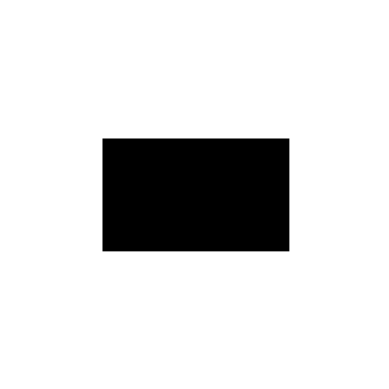

In [25]:
#image
image = np.ones((200,200), dtype=np.uint8)
cv.rectangle(image, (50,70), (150,130), 0, -1)

plt.imshow(image,cmap="gray")
plt.axis("off");


In [27]:
#Rotate image
angle = 45
theta = np.radians(angle)

#2x2
rotation_mat = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]
])
print(rotation_mat)

[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [29]:
from PIL.Image import new
#original image size
height,width = image.shape

new_width = int(
    abs(width * np.cos(theta))+
    abs(height * np.sin(theta))
)

new_height = int(
    abs(height * np.cos(theta)) +
    abs(height * np.sin(theta))
)

print("OG size : ",width , "x", height)
print("New Size: ", new_width, "x" , new_height)

OG size :  200 x 200
New Size:  282 x 282


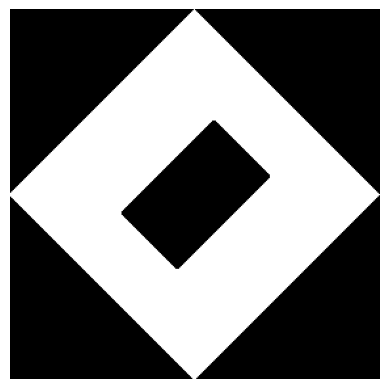

In [31]:
#Center
center = (width //2 , height //2 )
M = cv.getRotationMatrix2D(center, angle,1.0)
M[0,2] += (new_width - width)/2
M[1,2] += (new_height-height)/2

rotated = cv.warpAffine(image, M, (new_width, new_height))

plt.imshow(rotated, cmap="gray")
plt.axis("off");